# 03 · Limpieza

Toda transformación queda registrada: `limpieza.limpiar.limpiar()` devuelve el
DataFrame y un registro de qué hizo, con qué criterio y a cuántas filas afectó.

- **Se prefiere un NaN honesto a un valor inventado.** Solo se interpolan huecos
  de hasta 3 horas; los mayores se quedan vacíos y marcados.
- **Nada se elimina.** Atípicos y periodos estructurales se *marcan*; excluirlos
  es decisión del modelado.

In [1]:
import sys, warnings
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("ignore", category=FutureWarning)

DATASETS = RAIZ / "datasets"
print("raiz     :", RAIZ)
print("datasets :", DATASETS, "->", "existe" if DATASETS.exists() else "FALTA")

raiz     : C:\Users\manue\OneDrive\Documentos\PROYECTOS PORTAFOLIO REAL\SIEM EXPLORER
datasets : C:\Users\manue\OneDrive\Documentos\PROYECTOS PORTAFOLIO REAL\SIEM EXPLORER\datasets -> existe


In [2]:
from ingesta.normalizar import xm_cliente_a_esquema_comun

crudo_xm = pd.read_csv(DATASETS / "xm" / "xm_demareal_sistema.csv", parse_dates=["timestamp"])
xm = xm_cliente_a_esquema_comun(crudo_xm)
print(f"{len(xm):,} filas · {xm.fecha_hora.min()} .. {xm.fecha_hora.max()}")

from limpieza.limpiar import limpiar, procedencia, resumen as resumen_limpieza
limpio, registro = limpiar(xm)
print(resumen_limpieza(registro))

49,824 filas · 2021-01-01 00:00:00-05:00 .. 2026-09-07 23:00:00-05:00


REGISTRO DE LIMPIEZA
Momento : 2026-09-10T06:16:00
Filas   : 49,824 -> 49,824

[normalizar_esquema]  0 filas afectadas
  criterio: nombres a snake_case; marca de tiempo localizada en UTC-5; valor a float64
  columna_tiempo: fecha_hora
  columna_valor: valor_kwh
  zona_horaria: America/Bogota
  zona_ya_presente: True
  columnas_normalizadas_a_texto: ['fuente', 'metrica', 'entidad', 'version']

[deduplicar]  0 filas afectadas
  criterio: una fila por fecha_hora, conservando la ultima segun el orden de llegada
  filas_por_marca_antes: 1.0

[completar_rejilla]  0 filas afectadas
  criterio: rejilla horaria completa; imputacion 'temporal' solo para huecos de hasta 3 h; sin extrapolar en los extremos
  metodo_imputacion: temporal
  max_horas_interpolacion: 3

[marcar_atipicos]  321 filas afectadas
  criterio: atipico = |z modificada CAUSAL frente a (dia de semana, hora)| > 3.5, calculada solo con observaciones anteriores; atipico_iqr = fuera de 1.5 rangos intercuartilicos, tambien causal. Ma

## Qué hizo cada paso

El registro responde a «¿qué le pasó a estos datos?».

In [3]:
pd.DataFrame([
    {"operación": o["operacion"], "filas afectadas": o["filas_afectadas"], "criterio": o["criterio"]}
    for o in registro["operaciones"]
])

,operación,filas afectadas,criterio
0,normalizar_esquema,0,nombres a snake_case; marca de tiempo localiza...
1,deduplicar,0,"una fila por fecha_hora, conservando la ultima..."
2,completar_rejilla,0,rejilla horaria completa; imputacion 'temporal...
3,marcar_atipicos,321,atipico = |z modificada CAUSAL frente a (dia d...
4,marcar_periodo_atipico,0,periodo_atipico = fecha entre 2020-03-01 y 202...


## De dónde salió cada valor

La pregunta que la limpieza tiene que poder responder para cualquier celda.

In [4]:
print(limpio.origen_valor.value_counts().to_string())
print()
marcado = limpio[limpio.atipico].fecha_hora
muestras = [limpio.fecha_hora.iloc[0]] + ([marcado.iloc[-1]] if len(marcado) else [])
for momento in muestras:
    d = procedencia(limpio, momento)
    valor = f"{d['valor']:,.2f}" if d["valor"] is not None else "None"
    print(d["momento"])
    print(f"   valor {valor} · origen {d['origen_valor']} · atípico {d['atipico']} (z={d['z_estacional']})")
    print(f"   {d['explicacion']}")
    print()

origen_valor
observado    49824

2021-01-01 00:00:00-05:00
   valor 6,555,224.81 · origen observado · atípico False (z=None)
   Valor tal como lo publico la fuente; no se modifico.

2026-09-07 23:00:00-05:00
   valor 1,795,755.97 · origen observado · atípico True (z=-9.57)
   Valor tal como lo publico la fuente; no se modifico.



## ⚠️ Qué columnas NO usar como variables

`atipico_global` y `atipico_iqr_global` se calculan mirando **la serie entera**,
futuro incluido. Meterlas en un modelo es fuga temporal: el pasado quedaría
etiquetado con conocimiento del futuro y la validación saldría optimista.

Para eso están `atipico` y `atipico_iqr`, **causales**: cada fila se juzga solo
contra las observaciones anteriores de su grupo (día de semana, hora).

In [5]:
comparacion = pd.DataFrame({
    "causal (usar)":    [int(limpio.atipico.sum()), int(limpio.atipico_iqr.sum())],
    "global (no usar)": [int(limpio.atipico_global.sum()), int(limpio.atipico_iqr_global.sum())],
}, index=["estacional", "IQR"])
print(comparacion.to_string())
print()
print(f"filas aún no evaluables (grupo sin histórico): {int((~limpio.atipico_evaluable).sum()):,}")
print("-> son el arranque de la serie; tenlo en cuenta al partir train/test.")

            causal (usar)  global (no usar)
estacional            321               157
IQR                    48                48

filas aún no evaluables (grupo sin histórico): 3,360
-> son el arranque de la serie; tenlo en cuenta al partir train/test.


## La serie limpia

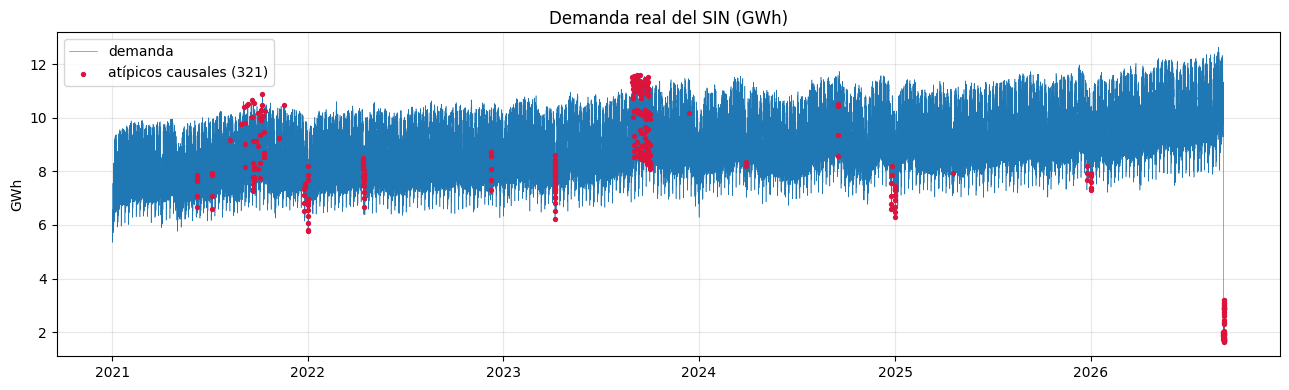

In [6]:
# Para graficar se pasa a hora local sin zona: matplotlib no acepta mezclar
# una linea de pandas con un scatter de fechas tz-aware en el mismo eje.
local = limpio.assign(hora_local=limpio.fecha_hora.dt.tz_localize(None))
marcados = local[local.atipico]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(local.hora_local, local.valor_kwh / 1e6, lw=.4, label="demanda")
ax.scatter(marcados.hora_local, marcados.valor_kwh / 1e6, c="crimson", s=8, zorder=5,
           label=f"atípicos causales ({len(marcados)})")
ax.set(title="Demanda real del SIN (GWh)", ylabel="GWh")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

## Siguiente paso

El panel de modelado —demanda limpia + clima + calendario, validando que el merge
no altera filas— se construye con `python scripts/construir_panel.py`.